# 03. 클러스터링 방법론 실험

Ko-SBERT 임베딩(768D) 데이터에 적합한 클러스터링 방법을 찾기 위해 여러 방법을 실험합니다.


**목표**: 덴드로그램 생성이 가능한 계층적 구조 + 의미적으로 분리된 클러스터
* 6만건이라 계산량 문제가 발생했었고 샘플링/압축 방식을 시작으로 우회하며 최적의 방법 탐색

| 실험 | 방법 | 결과 |
|------|------|------|
| 실험 1 | HAC(Ward) 직접 | 실루엣 0.01~0.04 |
| 실험 2 | PCA 256 + HAC(Ward) | 실루엣 마이너스 |
| 실험 3 | MiniBatchKMeans | 실루엣 0.03~0.07 |
| 실험 4 | HAC(Average + Cosine) | 실루엣 0.20~0.34 |
| **결론** | **-> UMAP + HDBSCAN 전환** | **04에서 진행** |

## 실험 1: 가장 기본적인 HAC(Ward) 시도

임베딩2(L2 정규화 O)에 HAC(Ward, 유클리드)를 직접 적용합니다. 6만건을 한번에 시도시 메모리문제가 생겨
2만 샘플 x 5회 반복으로 실루엣을 측정합니다.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# 임베딩 데이터 로드
df = pd.read_pickle('df_임베딩2.pkl')
X = np.vstack(df['vector'].values)
n = X.shape[0]
print(f'데이터: {X.shape}')

In [ ]:
# HAC(Ward)
k_range = list(range(2, 13))
sample_size = min(20000, n)
repeats = 5
use_l2_norm = True
rng = np.random.default_rng(42)

X_base = normalize(X, norm='l2', axis=1) if use_l2_norm else X

scores_per_k = {k: [] for k in k_range}

for r in range(repeats):
    idx = rng.choice(n, size=sample_size, replace=False)
    Xsam = X_base[idx]
    for k in tqdm(k_range, desc=f'[Agglo ward] repeat {r+1}/{repeats}'):
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(Xsam)
        s = silhouette_score(Xsam, labels, metric='euclidean')
        scores_per_k[k].append(float(s))

# 결과
k_list, mean_list, std_list = [], [], []
for k in k_range:
    arr = np.asarray(scores_per_k[k], dtype=float)
    k_list.append(k)
    mean_list.append(arr.mean())
    std_list.append(arr.std())

best_idx = int(np.nanargmax(mean_list))
print(f'Best k = {k_list[best_idx]} (mean={mean_list[best_idx]:.4f}, std={std_list[best_idx]:.4f})')

plt.figure(figsize=(7, 4))
plt.errorbar(k_list, mean_list, yerr=std_list, fmt='-o', capsize=4)
plt.xticks(k_list)
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette (mean +- std over repeats)')
plt.title(f'Agglomerative (ward) | sample={sample_size} x repeats={repeats}')
plt.grid(True, linestyle='--', alpha=0.35)
plt.show()

**실험 1 결과**: 실루엣 0.01~0.04로 매우 낮음. 고차원(768D) 텍스트 임베딩에 Ward linkage를 직접 적용하면 의미 있는 클러스터가 형성되지 않음.

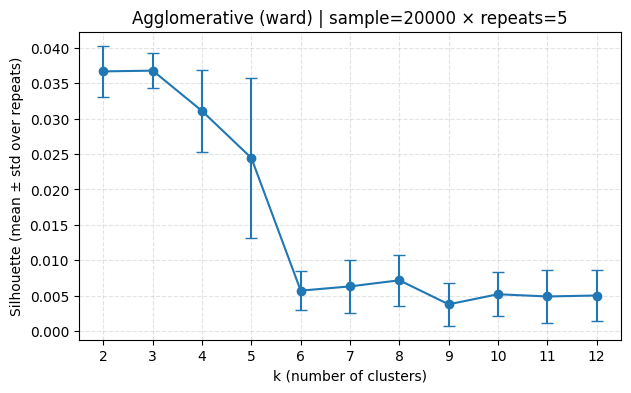

## 실험 2: PCA 차원축소 + HAC(Ward)

고차원이 문제일 수 있다는 가설로, PCA 256차원으로 축소 + StandardScaler 후 HAC(Ward)를 적용합니다.
3만 샘플 x 5회 반복.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.vstack(df['vector'].values).astype('float32')
n = X.shape[0]

# PCA 256차원 + StandardScaler
pca = PCA(n_components=256, svd_solver='randomized', whiten=False, random_state=42)
Xp = pca.fit_transform(X).astype(np.float32)
Xp = StandardScaler().fit_transform(Xp).astype(np.float32)
print(f'PCA cum.var: {pca.explained_variance_ratio_.sum():.4f}')

# HAC(Ward)
k_range = list(range(2, 10))
sample_size = min(30000, n)
repeats = 5
rng = np.random.default_rng(42)

scores_per_k = {k: [] for k in k_range}

for r in range(repeats):
    idx = rng.choice(n, size=sample_size, replace=False)
    Xsam = Xp[idx]
    for k in tqdm(k_range, desc=f'repeat {r+1}/{repeats}'):
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(Xsam)
        s = silhouette_score(Xsam, labels, metric='euclidean')
        scores_per_k[k].append(float(s))

k_list, mean_list, std_list = [], [], []
for k in k_range:
    arr = np.array(scores_per_k[k], dtype=float)
    k_list.append(k)
    mean_list.append(arr.mean())
    std_list.append(arr.std())

best_idx = int(np.argmax(mean_list))
print(f'Best k = {k_list[best_idx]} (mean={mean_list[best_idx]:.4f}, std={std_list[best_idx]:.4f})')

plt.figure(figsize=(7, 4))
plt.errorbar(k_list, mean_list, yerr=std_list, fmt='-o', capsize=4)
plt.xticks(k_list)
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score (mean +- std over repeats)')
plt.title(f'Silhouette vs k | sample=30,000 x repeats={repeats} (Agglo-ward)')
plt.grid(True, linestyle='--', alpha=0.35)
plt.show()

**실험 2 결과**: PCA로 차원을 축소하니 마이너스에서 0.01~0.04로 개선되었으나 여전히 낮음. 선형 차원축소(PCA)로는 비선형 구조를 보존할 수 없다는 한계.

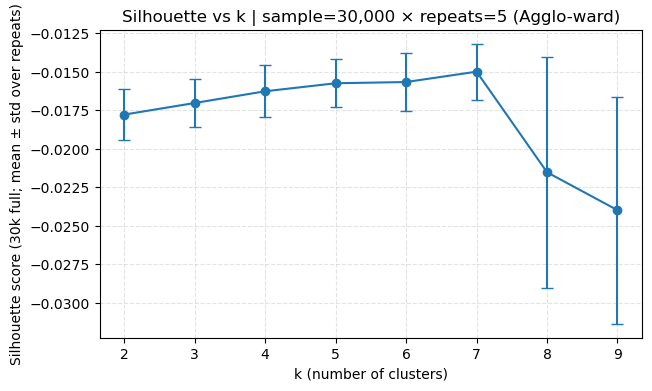

## 실험 3: MiniBatchKMeans

6만 건에 HAC를 직접 돌리기엔 계산량이 너무 크기 때문에 MiniBatchKMeans로 중심점을 압축한 뒤 HAC를 적용하려 했음
3만 샘플 x 5회 반복.


In [ ]:
from sklearn.cluster import MiniBatchKMeans

X = np.vstack(df['vector'].values).astype('float32')
n = X.shape[0]

k_range = list(range(2, 10))
sample_size = min(30000, n)
repeats = 5
batch_size = 4096
rng = np.random.default_rng(42)

scores_per_k = {k: [] for k in k_range}

for r in range(repeats):
    idx = rng.choice(n, size=sample_size, replace=False)
    Xsam = X[idx]
    for k in tqdm(k_range, desc=f'repeat {r+1}/{repeats}'):
        km = MiniBatchKMeans(
            n_clusters=k, batch_size=batch_size,
            n_init='auto', random_state=42 + r
        )
        labels = km.fit_predict(Xsam)
        s = silhouette_score(Xsam, labels, metric='euclidean')
        scores_per_k[k].append(s)

k_list, mean_list, std_list = [], [], []
for k in k_range:
    arr = np.array(scores_per_k[k], dtype=float)
    k_list.append(k)
    mean_list.append(arr.mean())
    std_list.append(arr.std())

best_idx = int(np.argmax(mean_list))
print(f'Best k = {k_list[best_idx]} (mean={mean_list[best_idx]:.4f}, std={std_list[best_idx]:.4f})')

plt.figure(figsize=(7, 4))
plt.errorbar(k_list, mean_list, yerr=std_list, fmt='-o', capsize=4)
plt.xticks(k_list)
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score (sample; mean +- std over repeats)')
plt.title(f'Silhouette vs k | {sample_size} sample x {repeats} repeats (MiniBatchKMeans)')
plt.grid(True, linestyle='--', alpha=0.35)
plt.show()

**실험 3 결과**:실루엣 0.03~0.07로 낮음. MiniBatchKMeans 자체 클러스터링 품질이 부족하므로, 이 중심점으로 HAC를 수행해도 의미 있는 결과를 기대하기 어렵다고 판단하여 이 방향을 포기.

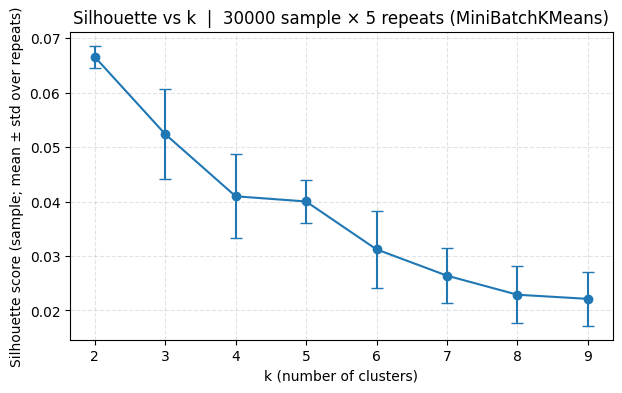

## 실험 4: HAC(Average + Cosine)

Ward linkage는 구형 클러스터를 가정하므로 텍스트 임베딩의 비구형 분포에 적합하지 않음.
Average linkage로 변경하여 클러스터 형태에 대한 가정을 완화하고, Cosine 거리를 사용


In [ ]:
# Average + Cosine (PCA 없이 원본 임베딩 사용)
X = np.vstack(df['vector'].values).astype('float32')
Xp = X  # PCA/표준화 없이 원본 임베딩 사용

n = Xp.shape[0]
k_range = list(range(2, 10))
sample_size = min(30000, n)
repeats = 5
rng = np.random.default_rng(42)

scores_per_k = {k: [] for k in k_range}

for r in range(repeats):
    idx = rng.choice(n, size=sample_size, replace=False)
    Xsam = Xp[idx]
    for k in tqdm(k_range, desc=f'repeat {r+1}/{repeats}'):
        model = AgglomerativeClustering(
            n_clusters=k, linkage='average', metric='cosine'
        )
        labels = model.fit_predict(Xsam)
        s = silhouette_score(Xsam, labels, metric='cosine')
        scores_per_k[k].append(float(s))

k_list, mean_list, std_list = [], [], []
for k in k_range:
    arr = np.array(scores_per_k[k], dtype=float)
    k_list.append(k)
    mean_list.append(arr.mean())
    std_list.append(arr.std())

best_idx = int(np.argmax(mean_list))
print(f'Best k = {k_list[best_idx]} (mean={mean_list[best_idx]:.4f}, std={std_list[best_idx]:.4f})')

# 시각화
k_arr = np.array(k_list)
mean_arr = np.array(mean_list)
std_arr = np.array(std_list)

plt.figure(figsize=(7, 4))
plt.plot(k_arr, mean_arr, '-o', linewidth=2.5, color='tab:blue', label='mean silhouette')
plt.fill_between(k_arr, mean_arr - std_arr, mean_arr + std_arr,
                 color='tab:blue', alpha=0.2, label='+-1 std')
plt.xticks(k_list)
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score (cosine)')
plt.title('Silhouette vs k (mean +- std) -- Average + Cosine')
plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.show()

**실험 4 결과**: 실루엣 0.20~0.34로 이전 실험 대비 큰 폭 개선. 그러나 k에 따른 명확한 엘보우(변곡점)가 없어서 최적 클러스터 수를 판단할 근거가 부족함.

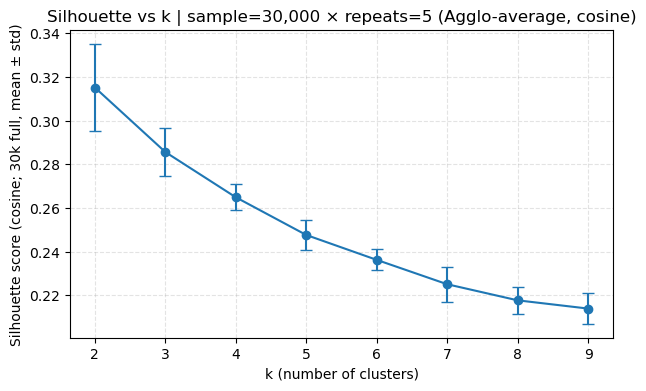

## 참고: 추가로 시도한 실험

위 4개 실험 외에도 아래 조합을 시도했으나 유의미한 개선이 없었음:

- MiniBatch KMeans로 중심점 압축(k=50~200) -> 중심점에 HAC(Ward) 적용 
- PCA 128차원 + StandardScaler/L2 정규화 유무 조합 
- 임베딩3(L2 정규화 X) + Ward + 유클리드 
- KNN connectivity (mutual/max) 시도하려 했으나 미완성

## 전체 실험 비교

| 방법 | Silhouette | 주요 한계 |
|------|-----------|----------|
| HAC(Ward) 직접 | 0.01~0.04 | 고차원(768D)에서 Ward linkage 성능 부족 |
| PCA 256 + HAC(Ward) | 마이너스 | 강제 차원축소로 정보 손실, 오히려 악화 |
| MiniBatchKMeans | 0.03~0.07 | 자체 성능 부족 → 중심점 압축 후 HAC 방향 포기 |
| **HAC(Average + Cosine)** | **0.20~0.34** | **가장 양호하나 k값 선택에 어려움** |

### 결론

1. **linkage 방식**: Ward(구형 가정) → Average(가정 완화)로 변경 시 성능 대폭 개선. 텍스트 임베딩의 비구형 분포에는 Average linkage가 더 적합.
2. **차원축소**: PCA(선형)로는 비선형 구조를 보존할 수 없음
3. **한계**: Average + Cosine도 실루엣 0.3 수준이지만 변곡점을 찾을 수 없어 k를 선택하기 어려웠음

-> **UMAP(비선형 차원축소) + HDBSCAN(밀도 기반, 클러스터 수 자동 결정)** 으로 전환합니다. (04_umap_hdbscan.ipynb)